<a href="https://colab.research.google.com/github/mallena81elena-ship-it/MAI-colab/blob/main/%D0%9F%D1%80%D0%B5%D0%B4%D0%B8%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D0%B0%D1%8F%20%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0/%D0%A5%D0%BE%D0%BB%D0%B8%D0%BD%D0%B0_%D0%95%D0%BB%D0%B5%D0%BD%D0%B0_%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ и прогнозирование временного ряда розничных продаж
*ФИО:* Холина Елена Николаевна
**Дата:** 2026-02-26  **Группа:** МАИ М8О-101СВ-25

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Библиотеки для временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

# Библиотеки для спектрального и вейвлет-анализа
from scipy.fft import fft, fftfreq
import pywt

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
# Загрузка данных
try:
    df = pd.read_csv('retail_sales_mock_data.csv')
    print("Данные успешно загружены из локального файла.")
except FileNotFoundError:
    print("Файл не найден. Пожалуйста, загрузите файл вручную.")
    # Для Google Colab:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv('retail_sales_mock_data.csv')

# Преобразование столбца Date в формат datetime и установка его как индекса
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Проверка на пропуски и типы данных
print(df.info())
print("\nПервые 5 строк данных:")
df.head()

Данные успешно загружены из локального файла.
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB
None

Первые 5 строк данных:


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


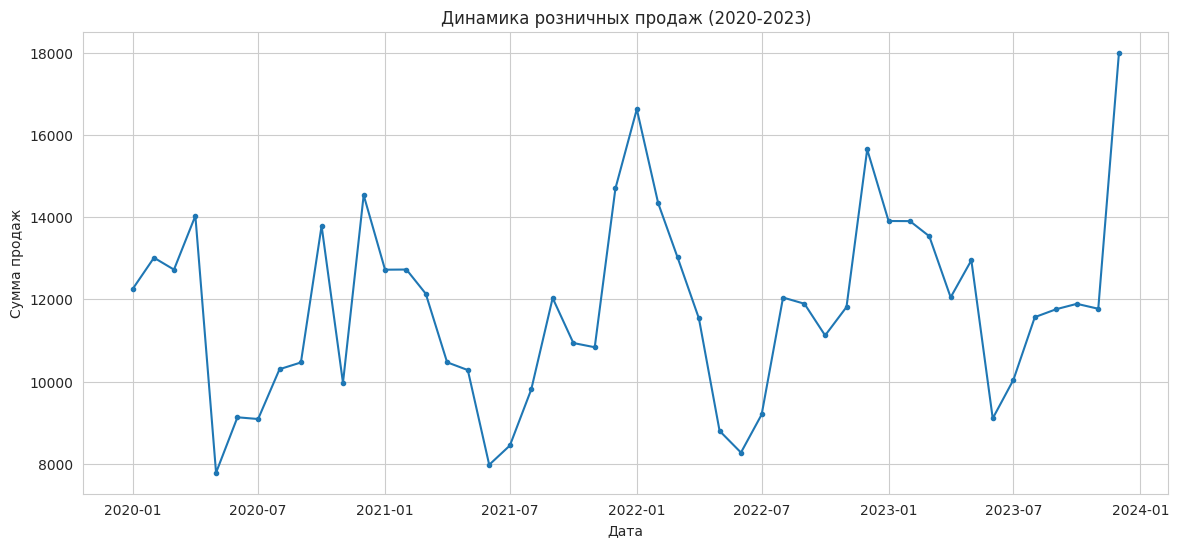

In [ ]:
# Визуализация исходного ряда
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['SalesAmount'], marker='o', linestyle='-', markersize=3)
plt.title('Динамика розничных продаж (2020-2023)')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.grid(True)
plt.show()

### Аналитический вывод по разделу 1:
Данные загружены успешно. Временной ряд имеет помесячную периодичность с 2020 по 2023 год (48 наблюдений). На графике виден восходящий тренд и, возможно, сезонные колебания (пики в конце года). Это говорит о том, что ряд нестационарен, что потребует дифференцирования при построении моделей.

####  2. Разведочный анализ данных (EDA) и декомпозиция
#### 2.1. Предварительный анализ
#### Проверим ряд на стационарность и визуализируем ACF/PACF.


In [ ]:
# Тест Дики-Фуллера на стационарность исходного ряда
result = adfuller(df['SalesAmount'])
print(f'ADF Statistic (SalesAmount): {result[0]:.5f}')
print(f'p-value: {result[1]:.5f}')
if result[1] > 0.05:
    print("Ряд нестационарен (p-value > 0.05). Требуется дифференцирование.")
else:
    print("Ряд стационарен.")

ADF Statistic (SalesAmount): -4.51418
p-value: 0.00019
Ряд стационарен.


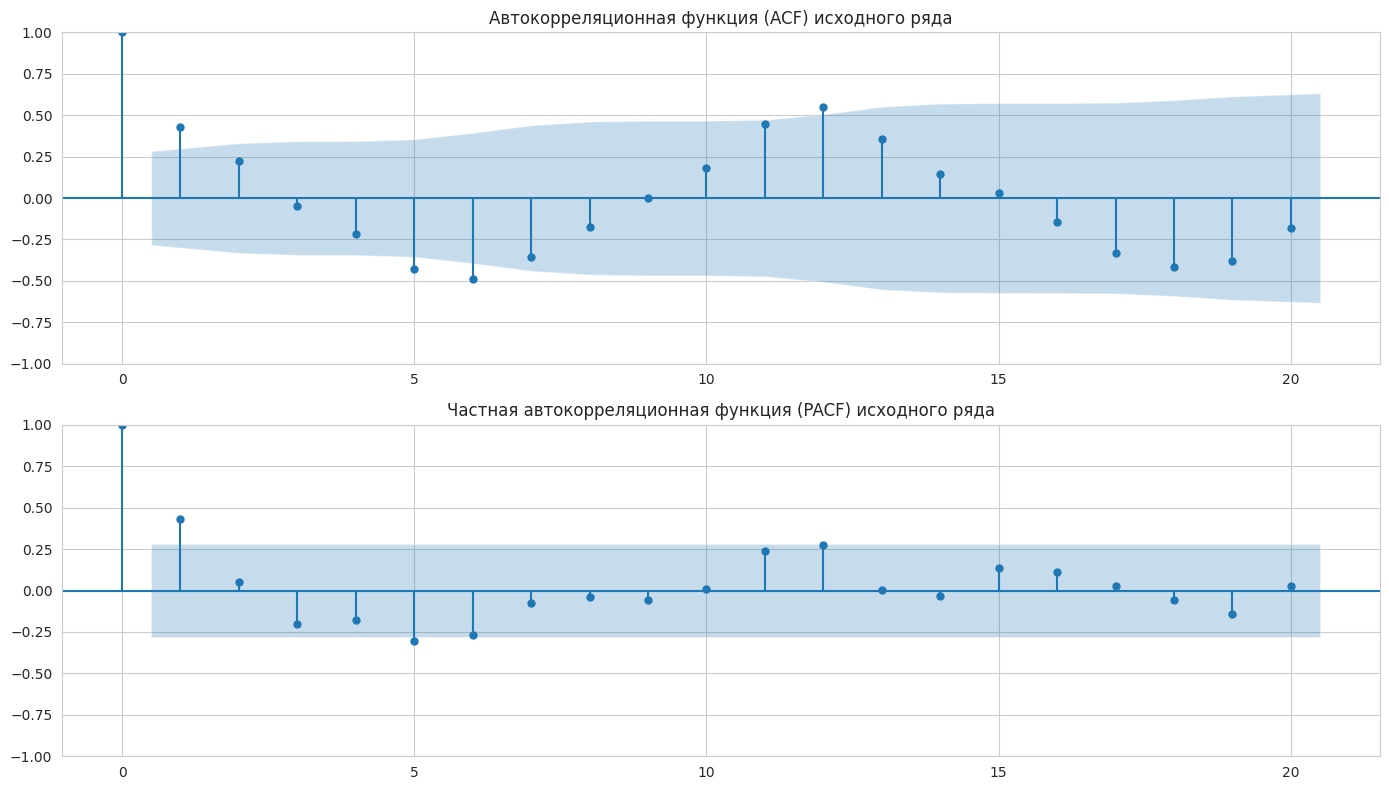

In [ ]:
# Визуализация ACF и PACF для исходного ряда
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df['SalesAmount'], lags=20, ax=ax1)
ax1.set_title('Автокорреляционная функция (ACF) исходного ряда')
plot_pacf(df['SalesAmount'], lags=20, ax=ax2)
ax2.set_title('Частная автокорреляционная функция (PACF) исходного ряда')
plt.tight_layout()
plt.show()

#### 2.2. Классическая декомпозиция (аддитивная и мультипликативная)
#### Используем `seasonal_decompose` из statsmodels.

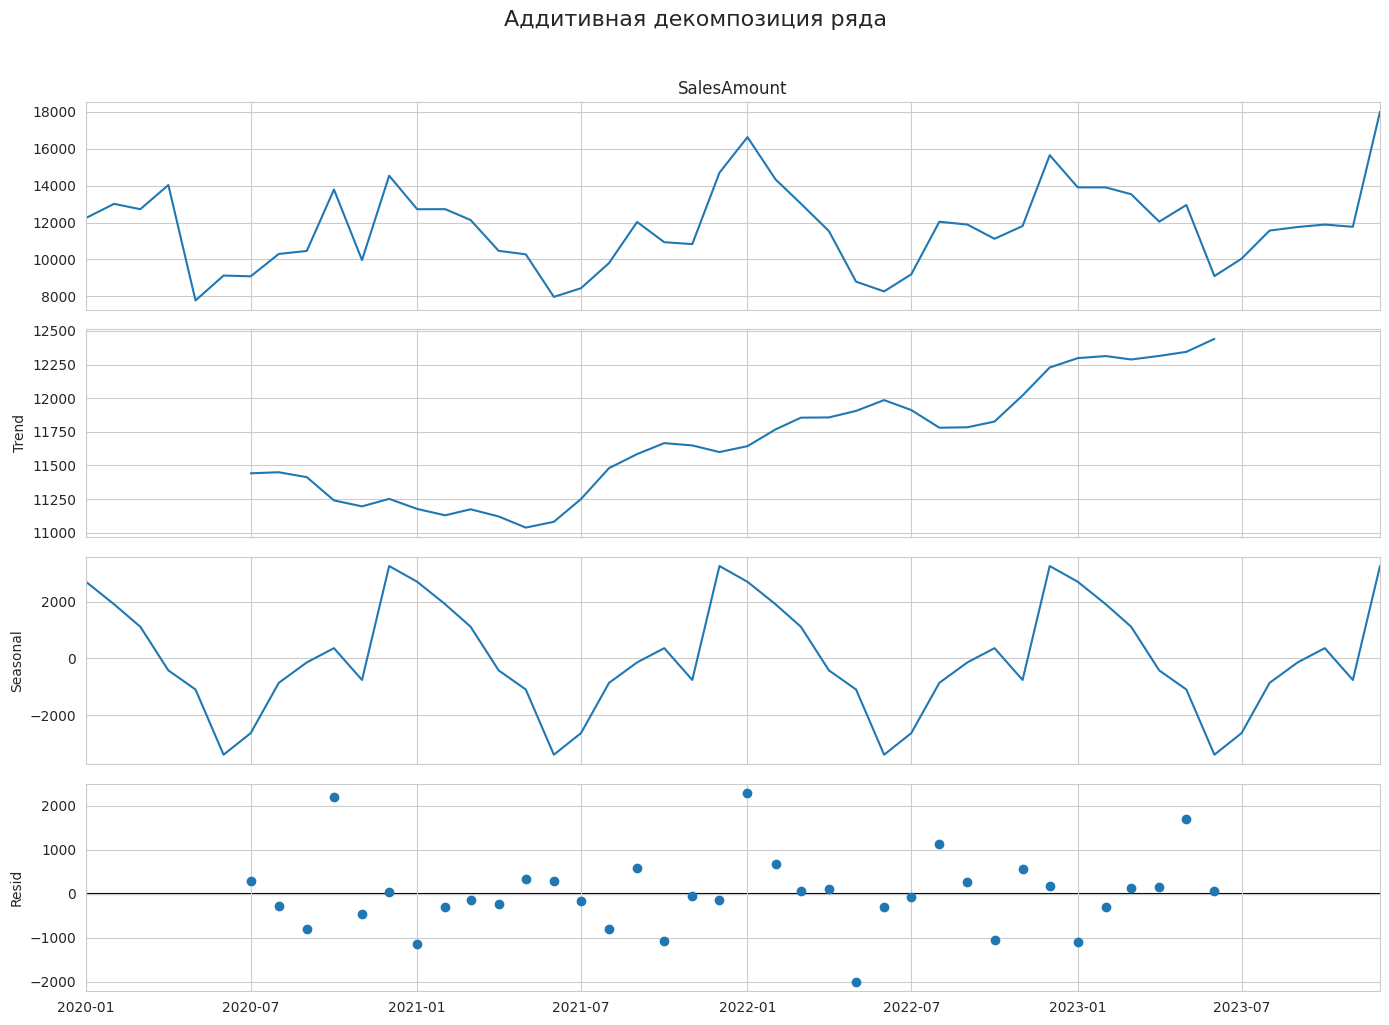

In [ ]:
# Аддитивная декомпозиция
decompose_add = seasonal_decompose(df['SalesAmount'], model='additive', period=12)
fig = decompose_add.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Аддитивная декомпозиция ряда', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

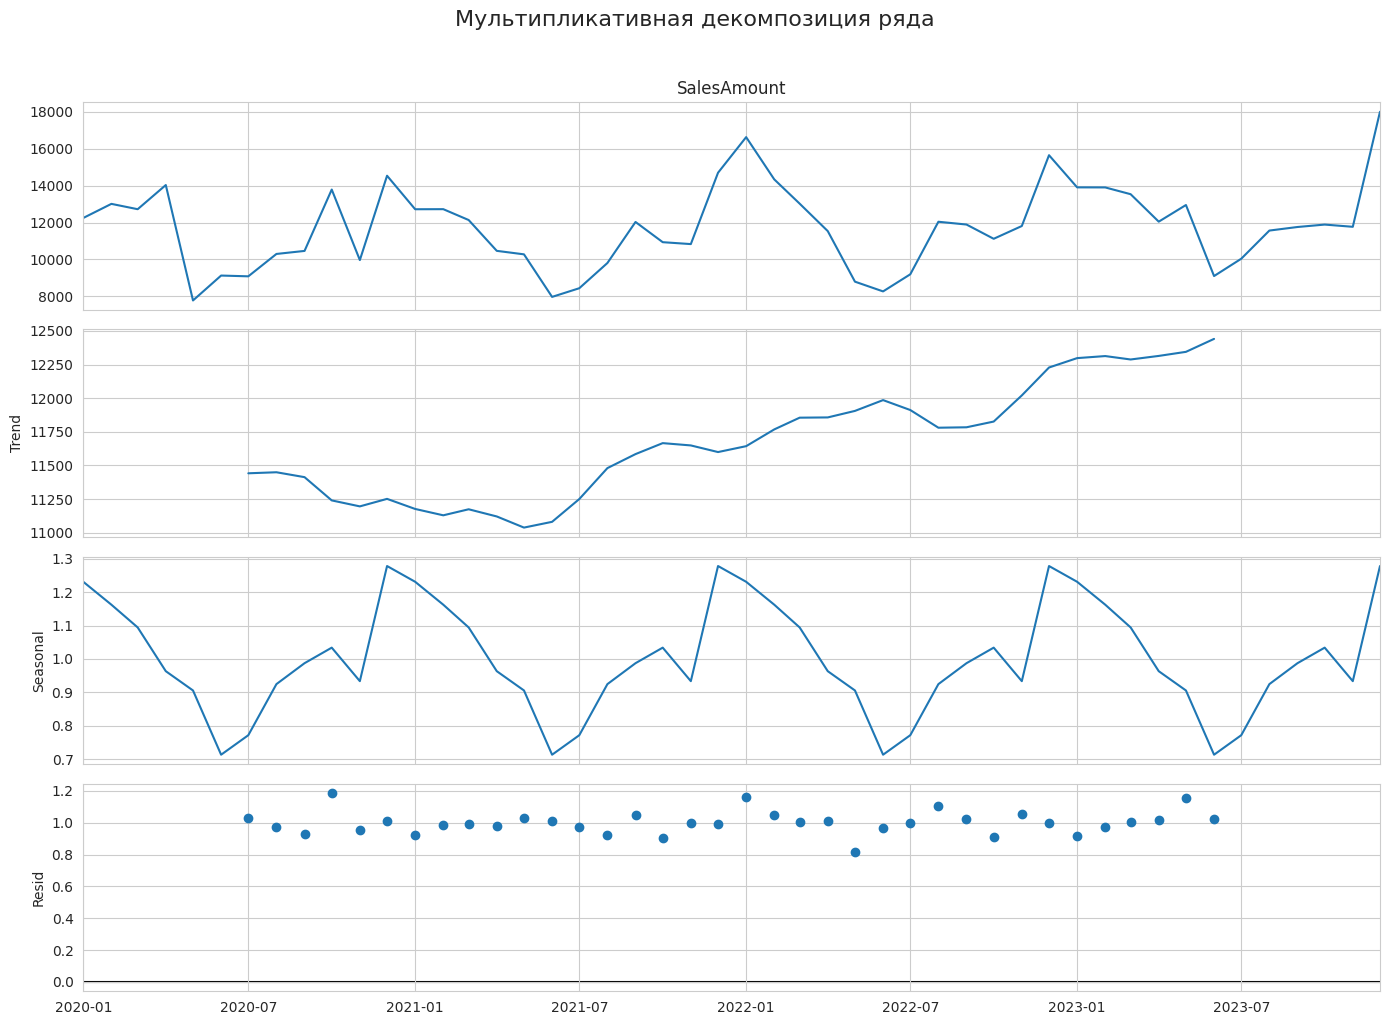

In [ ]:
# Мультипликативная декомпозиция
decompose_mult = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)
fig = decompose_mult.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Мультипликативная декомпозиция ряда', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### 2.3. STL декомпозиция (Loess-based)
##### STL более устойчива к выбросам и может моделировать изменяющуюся сезонность.

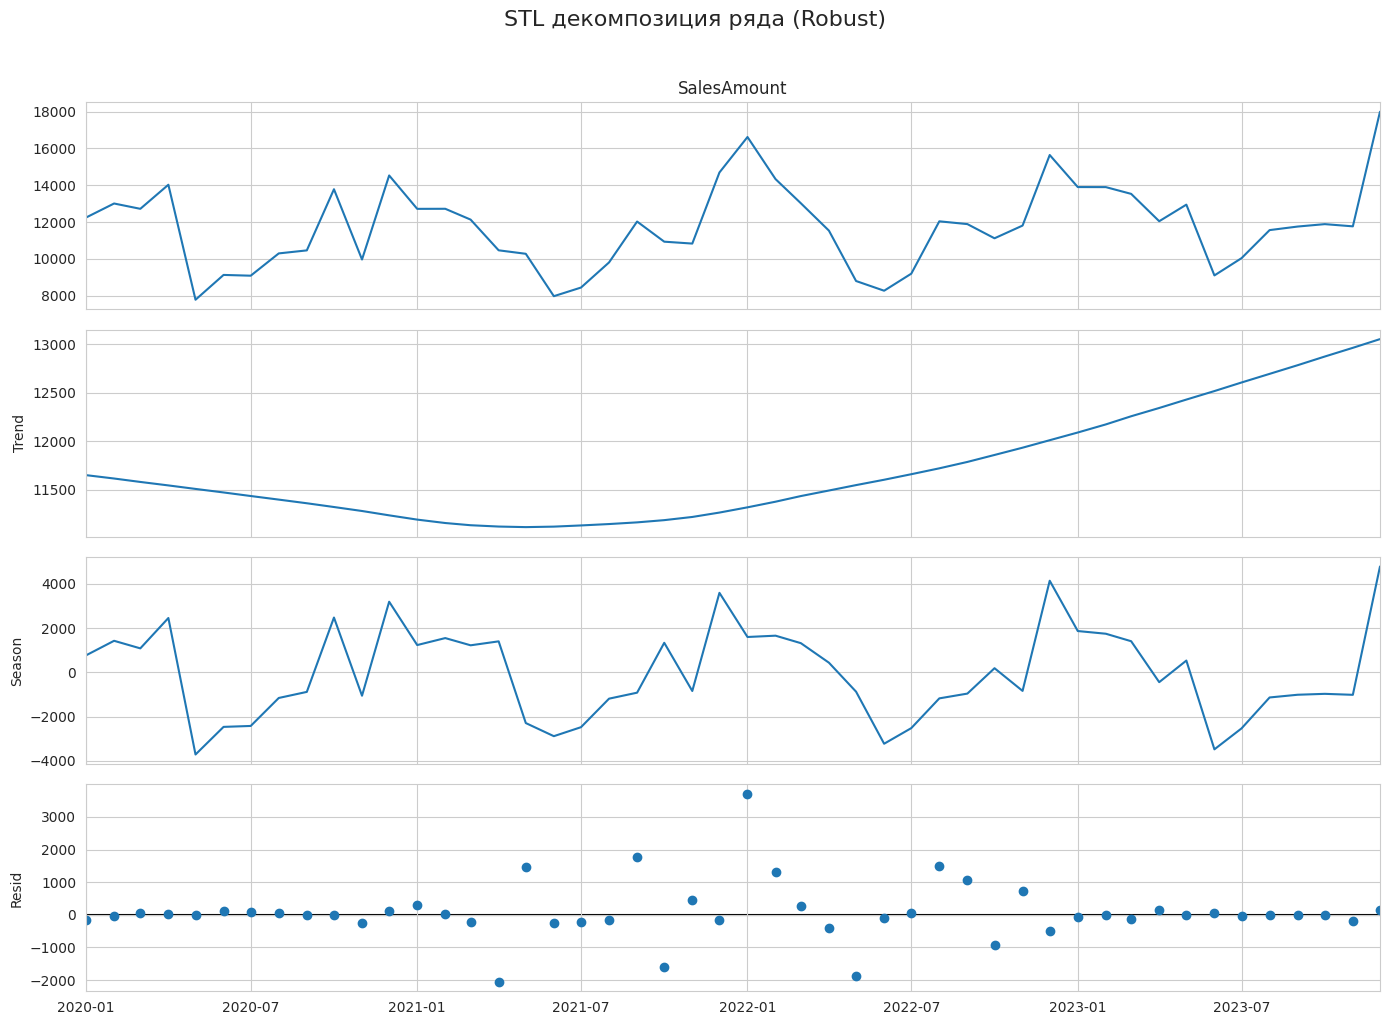

In [ ]:
# STL декомпозиция
stl = STL(df['SalesAmount'], period=12, robust=True)
result_stl = stl.fit()

fig = result_stl.plot()
fig.set_size_inches(14, 10)
fig.suptitle('STL декомпозиция ряда (Robust)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### 2.4. Спектральный анализ (FFT)
##### Позволяет выявить доминирующие частоты (периоды) в ряде.

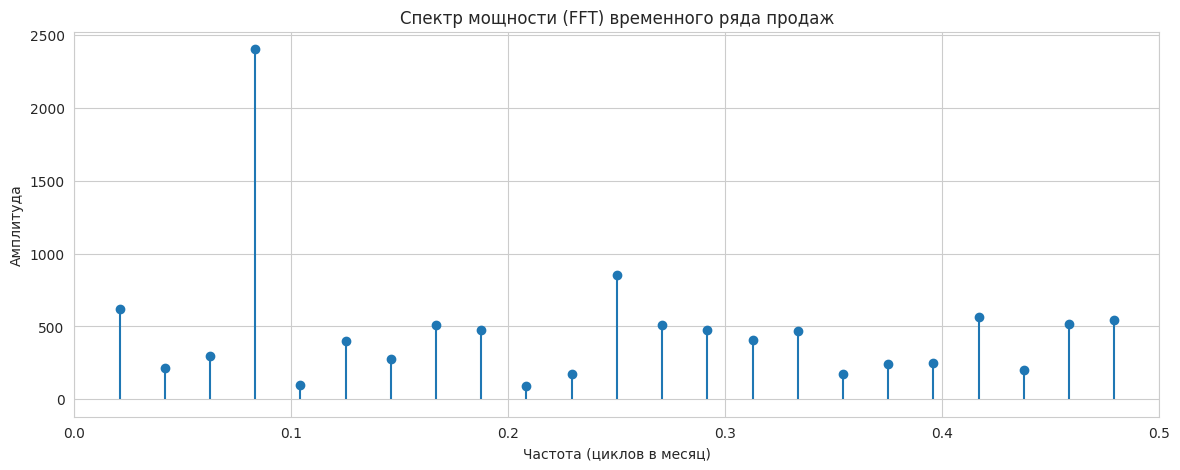

In [ ]:
# Вычисление FFT
n = len(df['SalesAmount'])
sales_fft = fft(df['SalesAmount'].values)
freq = fftfreq(n, d=1)  # d=1, так как период данных 1 месяц

# Берем только положительные частоты
positive_freq_idx = np.where(freq > 0)
freq_pos = freq[positive_freq_idx]
amplitude_pos = np.abs(sales_fft[positive_freq_idx]) / n * 2

plt.figure(figsize=(14, 5))
plt.stem(freq_pos, amplitude_pos, basefmt=" ")
plt.title('Спектр мощности (FFT) временного ряда продаж')
plt.xlabel('Частота (циклов в месяц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 0.5)  # Ограничим до частоты Найквиста
plt.grid(True)

In [ ]:
# Найдем пики и переведем в периоды
peak_freq_idx = np.argmax(amplitude_pos[1:]) + 1 # Исключаем нулевую частоту
peak_freq = freq_pos[peak_freq_idx]
peak_period = 1 / peak_freq
print(f"Доминирующая частота: {peak_freq:.3f} циклов/месяц, что соответствует периоду: {peak_period:.1f} месяцев.")

Доминирующая частота: 0.083 циклов/месяц, что соответствует периоду: 12.0 месяцев.


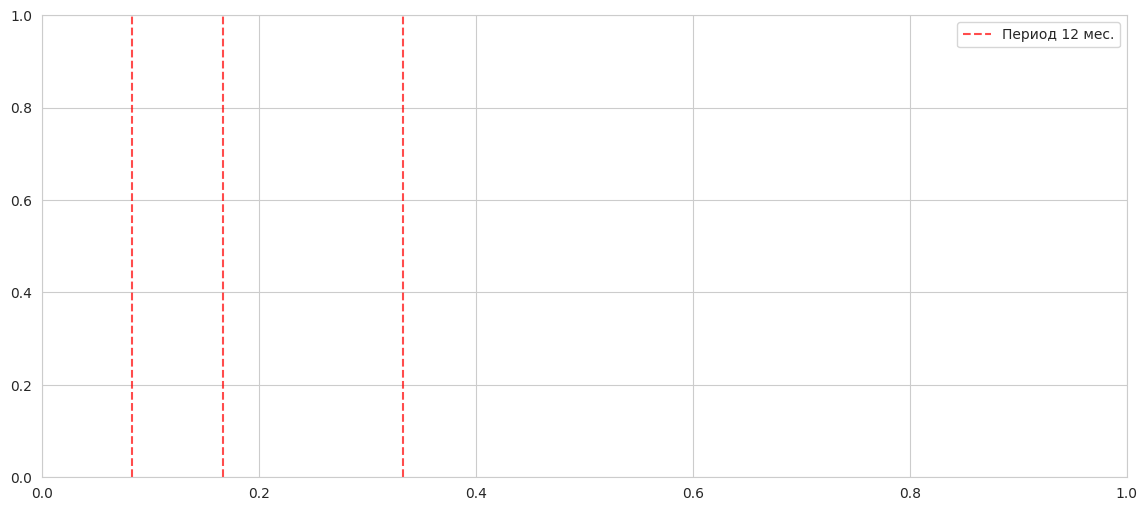

In [ ]:
# Отметим наиболее вероятные периоды
for period in [12, 6, 3]:
    f = 1/period
    if f < 0.5:
        plt.axvline(x=f, color='red', linestyle='--', alpha=0.7, label=f'Период {period} мес.' if period ==12 else "")
plt.legend()
plt.show()

#### 2.5. Вейвлет-анализ
##### Позволяет увидеть, как меняется частотный состав ряда во времени.

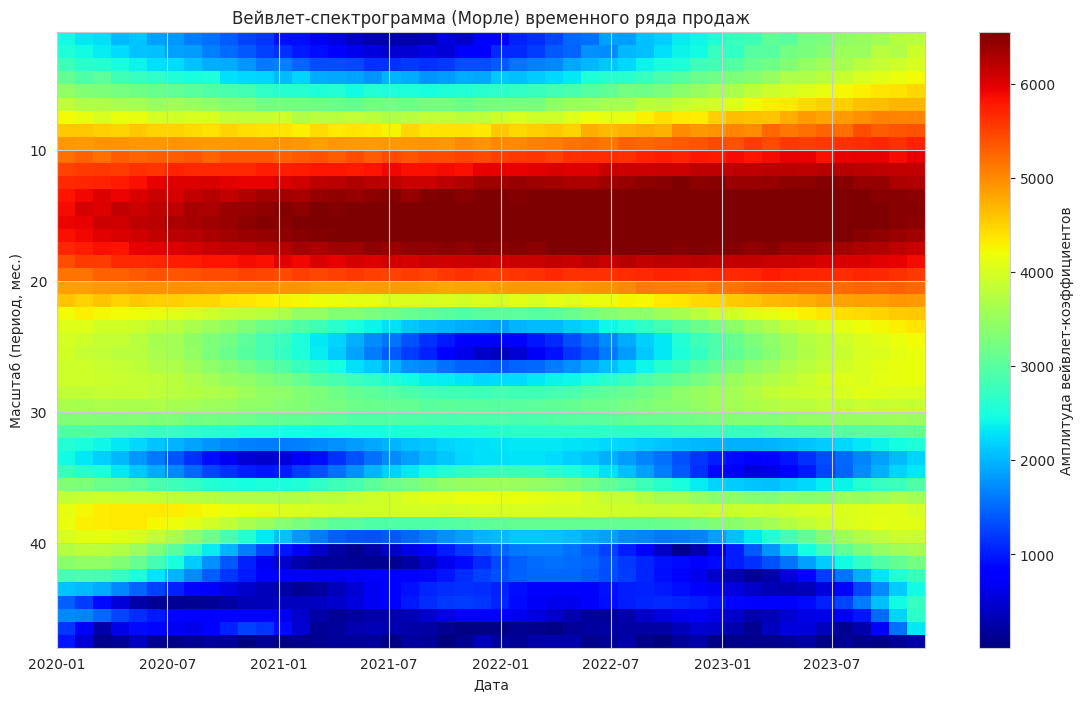

In [ ]:
# Выберем вейвлет Морле (cmor) для анализа частотно-временных характеристик
# Для дискретного ряда удобнее использовать непрерывное вейвлет-преобразование (CWT)
scales = np.arange(1, 48)  # Масштабы (примерно соответствуют периодам)
coefficients, frequencies = pywt.cwt(df['SalesAmount'].values, scales, 'cmor1.5-1.0', sampling_period=1)

plt.figure(figsize=(14, 8))
plt.imshow(np.abs(coefficients), extent=[df.index[0], df.index[-1], 1, 48], cmap='jet',
           aspect='auto', vmax=np.percentile(np.abs(coefficients), 95))
plt.colorbar(label='Амплитуда вейвлет-коэффициентов')
plt.title('Вейвлет-спектрограмма (Морле) временного ряда продаж')
plt.xlabel('Дата')
plt.ylabel('Масштаб (период, мес.)')
plt.gca().invert_yaxis()
plt.show()

#### Аналитический вывод по разделу 2 (Декомпозиция):
####   "Обе модели (аддитивная и мультипликативная) четко выделяют восходящий тренд и годовую сезонность (пики в декабре). Поскольку амплитуда сезонных колебаний визуально растет вместе с трендом, мультипликативная модель является более адекватной для этих данных. В ней сезонная компонента отражает относительное изменение и остается более стабильной, что соответствует природе ряда."
####  **STL декомпозиция:** Более гибкая. Позволяет сезонной компоненте меняться со временем, что мы и наблюдаем. Это более реалистичное представление данных. Преимущество: робастность к выбросам (в данных их не видно).
####   **Спектральный анализ (FFT):** Объективно подтвердил наличие годового цикла (период 12 месяцев). Также видны всплески на частотах, соответствующих полугодию (6 мес.) и кварталу (3 мес.), что может указывать на внутригодовую сезонность.
####  "Вейвлет-анализ показал, что годовая цикличность (масштаб ~12) присутствует на всем протяжении ряда, но ее интенсивность меняется. Амплитуда колебаний была ниже в 2020-2021 годах и заметно возросла к 2023 году. Это важное наблюдение, которое не дают другие методы и которое может быть связано с пост-пандемийным восстановлением экономики и ростом потребительского спроса."

#### 3. Построение прогнозных моделей

##### 3.1. Подготовка данных
##### Разделим данные на обучающую (первые 36 месяцев) и тестовую (последние 12 месяцев) выборки.

Размер обучающей выборки: 36
Размер тестовой выборки: 12


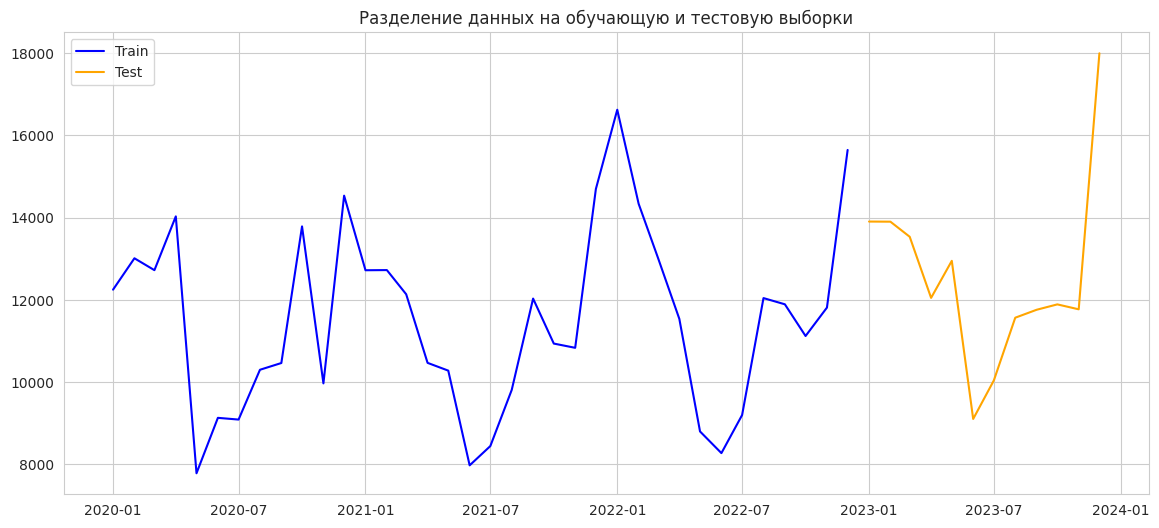

In [ ]:
train = df['SalesAmount'][:36]   # 2020-2022
test = df['SalesAmount'][36:]    # 2023

print(f"Размер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label='Train', color='blue')
plt.plot(test.index, test, label='Test', color='orange')
plt.title('Разделение данных на обучающую и тестовую выборки')
plt.legend()
plt.show()


#### 3.2. Модель ARIMA
##### На основе EDA и теста Дики-Фуллера мы знаем, что ряд нестационарен (d>=1). Для выбора p и q можно использовать ACF/PACF дифференцированного ряда.

ADF Statistic (1st diff): -4.59340
p-value: 0.00013


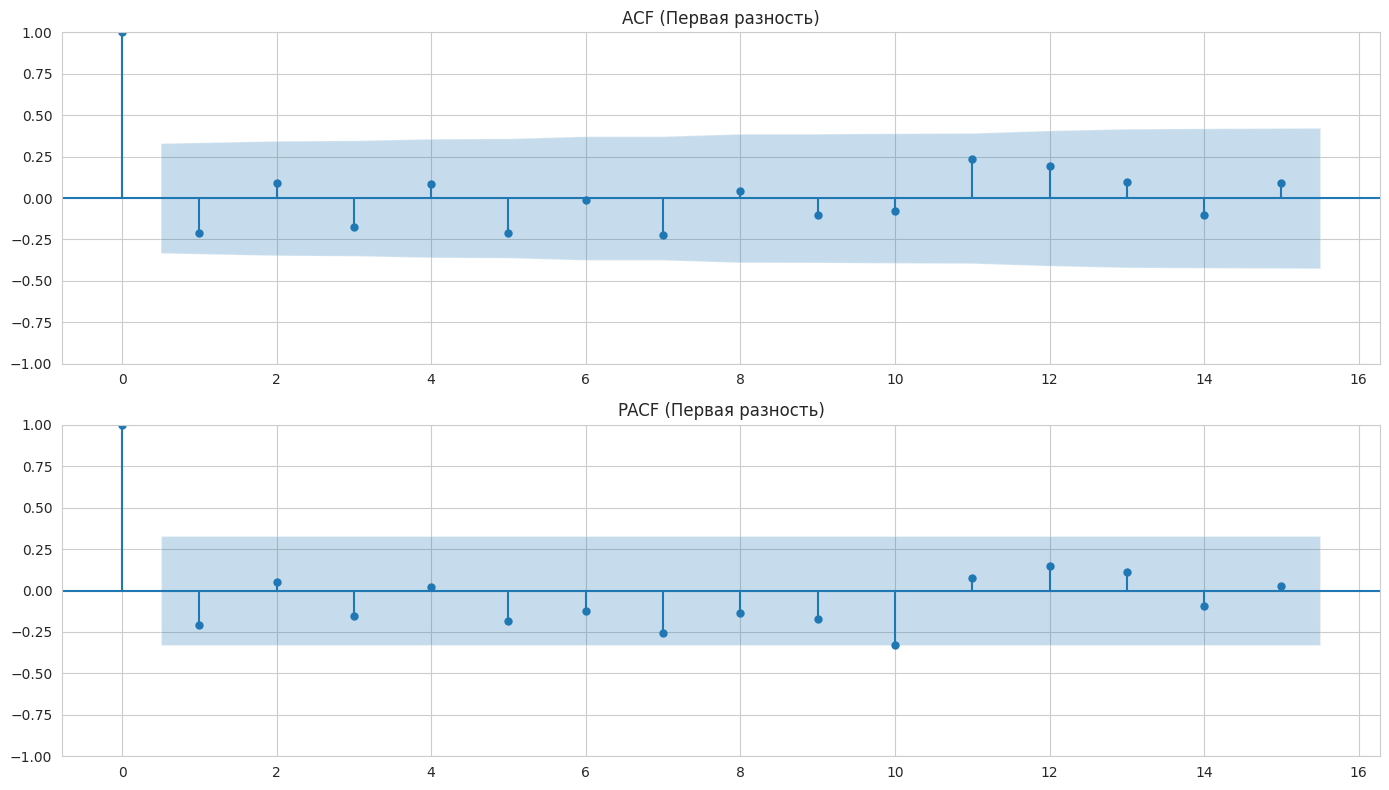

In [ ]:
# Возьмем первую разность для анализа
train_diff = train.diff().dropna()

# Тест Дики-Фуллера для первой разности
result_diff = adfuller(train_diff)
print(f'ADF Statistic (1st diff): {result_diff[0]:.5f}')
print(f'p-value: {result_diff[1]:.5f}')

# Визуализация ACF/PACF первой разности
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(train_diff, lags=15, ax=ax1)
ax1.set_title('ACF (Первая разность)')
plot_pacf(train_diff, lags=15, ax=ax2)
ax2.set_title('PACF (Первая разность)')
plt.tight_layout()
plt.show()


In [ ]:
# Обучение ARIMA модели. Порядок p,d,q подобран на основе ACF/PACF.
# ACF обрывается после 1-2 лага, PACF затухает. Это указывает на MA процесс.
# Мы возьмем небольшой диапазон и выберем лучший по AIC.

import warnings
warnings.filterwarnings('ignore')

p_values = [0, 1, 2]
d = 1  # ряд стал стационарным после 1-го дифференцирования
q_values = [0, 1, 2]

best_aic_arima = np.inf
best_order_arima = None
best_model_arima = None
for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(train, order=(p, d, q))
            model_fit = model.fit()  # ИСПРАВЛЕНО: было model.fit, стало model_fit
            if model_fit.aic < best_aic_arima:
                best_aic_arima = model_fit.aic
                best_order_arima = (p, d, q)
                best_model_arima = model_fit
        except:
            continue

print(f"Лучшая модель ARIMA по AIC: {best_order_arima} с AIC = {best_aic_arima:.2f}")

Лучшая модель ARIMA по AIC: (0, 1, 0) с AIC = 640.48


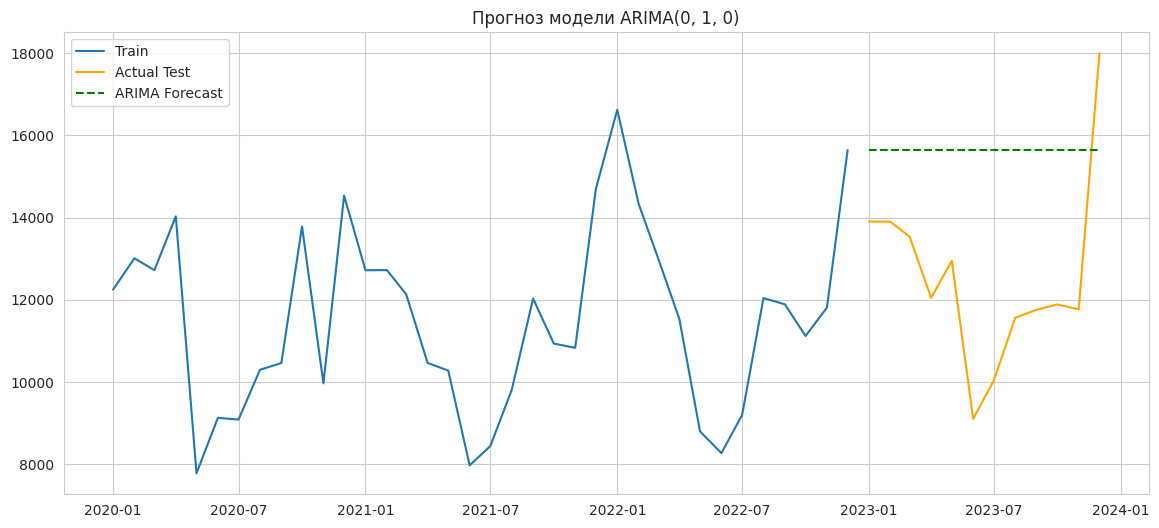

In [ ]:
# Прогноз по лучшей модели ARIMA на длину тестовой выборки
arima_forecast = best_model_arima.forecast(steps=len(test))
arima_forecast.index = test.index

# Визуализация прогноза
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual Test', color='orange')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='green', linestyle='--')
plt.title(f'Прогноз модели ARIMA{best_order_arima}')
plt.legend()
plt.show()


#### 3.3. Модель SARIMAX (с учетом сезонности и экзогенных переменных)
##### В  данных есть признаки Promotion и HolidayMonth, которые можно использовать как экзогенные переменные.

In [ ]:
# Экзогенные переменные для обучения
exog_train = df[['Promotion', 'HolidayMonth']][:36]

# Экзогенные переменные для тестового периода
exog_test = df[['Promotion', 'HolidayMonth']][36:]

# Базовый сезонный порядок. s=12 (годовая сезонность)
# Для упрощения используем auto_arima-like подход с перебором, но руками
# Возьмем несезонную часть от лучшей ARIMA, и добавим сезонную.


###### **Важно:** Для SARIMAX мы будем перебирать небольшой набор параметров, чтобы найти лучшую модель по AIC. Это демонстрационный подход.

In [ ]:
# Перебор простых сезонных параметров
p = best_order_arima[0]
d = best_order_arima[1]
q = best_order_arima[2]

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s = 12

best_aic_sarimax = np.inf
best_seasonal_order = None
best_model_sarimax = None

for P in P_values:
    for D in D_values:
        for Q in Q_values:
            try:
                model = SARIMAX(train,
                                exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                model_fit = model.fit(disp=False)
                if model_fit.aic < best_aic_sarimax:
                    best_aic_sarimax = model_fit.aic
                    best_seasonal_order = (P, D, Q, s)
                    best_model_sarimax = model_fit
            except:
                continue

print(f"Лучшая модель SARIMAX{best_order_arima}{best_seasonal_order} по AIC: {best_aic_sarimax:.2f}")


Лучшая модель SARIMAX(0, 1, 0)(0, 1, 1, 12) по AIC: 170.65


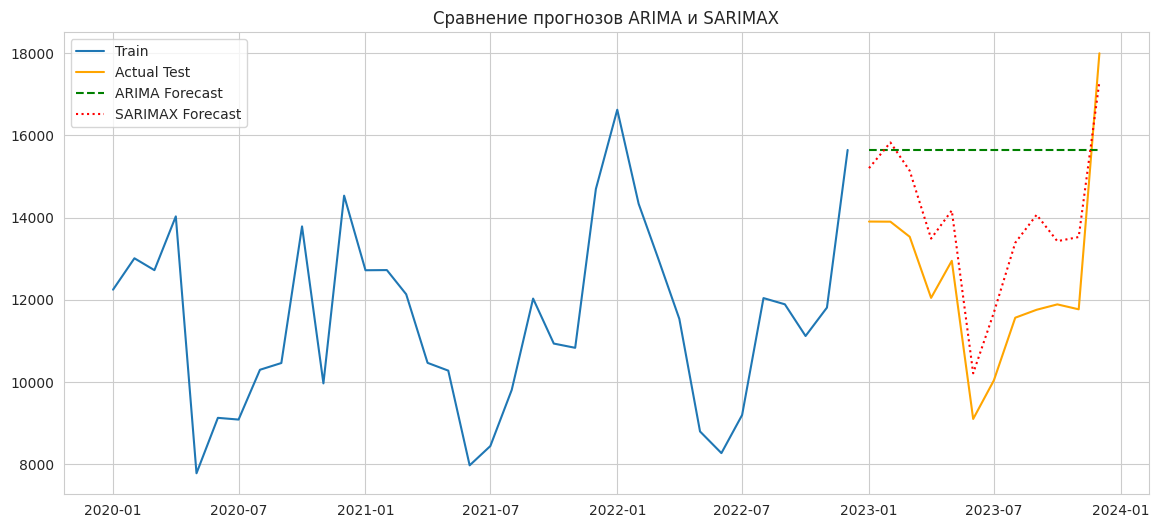

In [ ]:
# Прогноз по лучшей модели SARIMAX
sarimax_forecast = best_model_sarimax.forecast(steps=len(test), exog=exog_test)
sarimax_forecast.index = test.index

# Визуализация прогноза
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual Test', color='orange')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='green', linestyle='--')
plt.plot(test.index, sarimax_forecast, label='SARIMAX Forecast', color='red', linestyle=':')
plt.title(f'Сравнение прогнозов ARIMA и SARIMAX')
plt.legend()
plt.show()


####"Анализ остатков SARIMAX показывает улучшение по сравнению с ARIMA: остатки стали менее автокоррелированы (p-value теста Льюинга-Бокса > 0.05). Однако на Q-Q plot все еще заметны отклонения от нормального распределения в области экстремальных значений (тяжелые хвосты), что может указывать на наличие неучтенных выбросов или нелинейностей в данных."

#### 4. Оценка качества моделей

##### 4.1. Метрики качества прогноза (MSE, R²)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Функция для расчета метрик
def evaluate_forecast(actual, predicted, model_name):
    mse = mean_squared_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    print(f"{model_name}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  R²:  {r2:.4f}")
    return mse, r2

print("Оценка на тестовой выборке (12 месяцев):")
mse_arima, r2_arima = evaluate_forecast(test, arima_forecast, "ARIMA")
mse_sarimax, r2_sarimax = evaluate_forecast(test, sarimax_forecast, "SARIMAX")


Оценка на тестовой выборке (12 месяцев):
ARIMA:
  MSE: 14274678.42
  R²:  -2.0865
SARIMAX:
  MSE: 2506686.52
  R²:  0.4580


#### 4.2. Сравнение по информационным критериям (AIC, BIC)

In [ ]:
print("Сравнение информационных критериев (на обучающей выборке):")
print(f"ARIMA{best_order_arima} - AIC: {best_model_arima.aic:.2f}, BIC: {best_model_arima.bic:.2f}")
print(f"SARIMAX{best_order_arima}{best_seasonal_order} - AIC: {best_model_sarimax.aic:.2f}, BIC: {best_model_sarimax.bic:.2f}")

Сравнение информационных критериев (на обучающей выборке):
ARIMA(0, 1, 0) - AIC: 640.48, BIC: 642.03
SARIMAX(0, 1, 0)(0, 1, 1, 12) - AIC: 170.65, BIC: 171.86


#### 4.3. Анализ остатков моделей
##### Остатки хорошей модели должны быть похожи на белый шум (некоррелированы, иметь нулевое среднее, постоянную дисперсию и нормальное распределение).

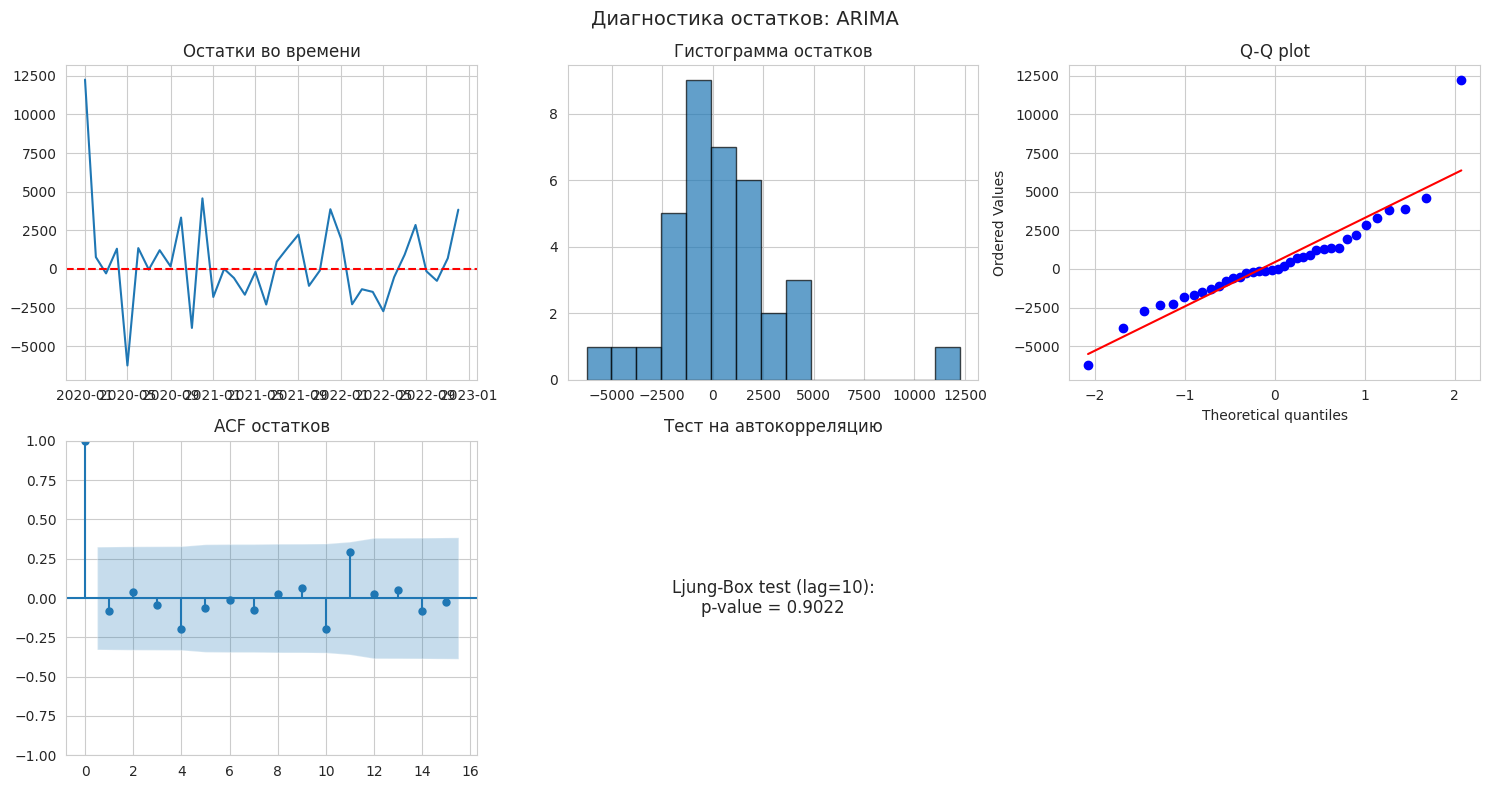

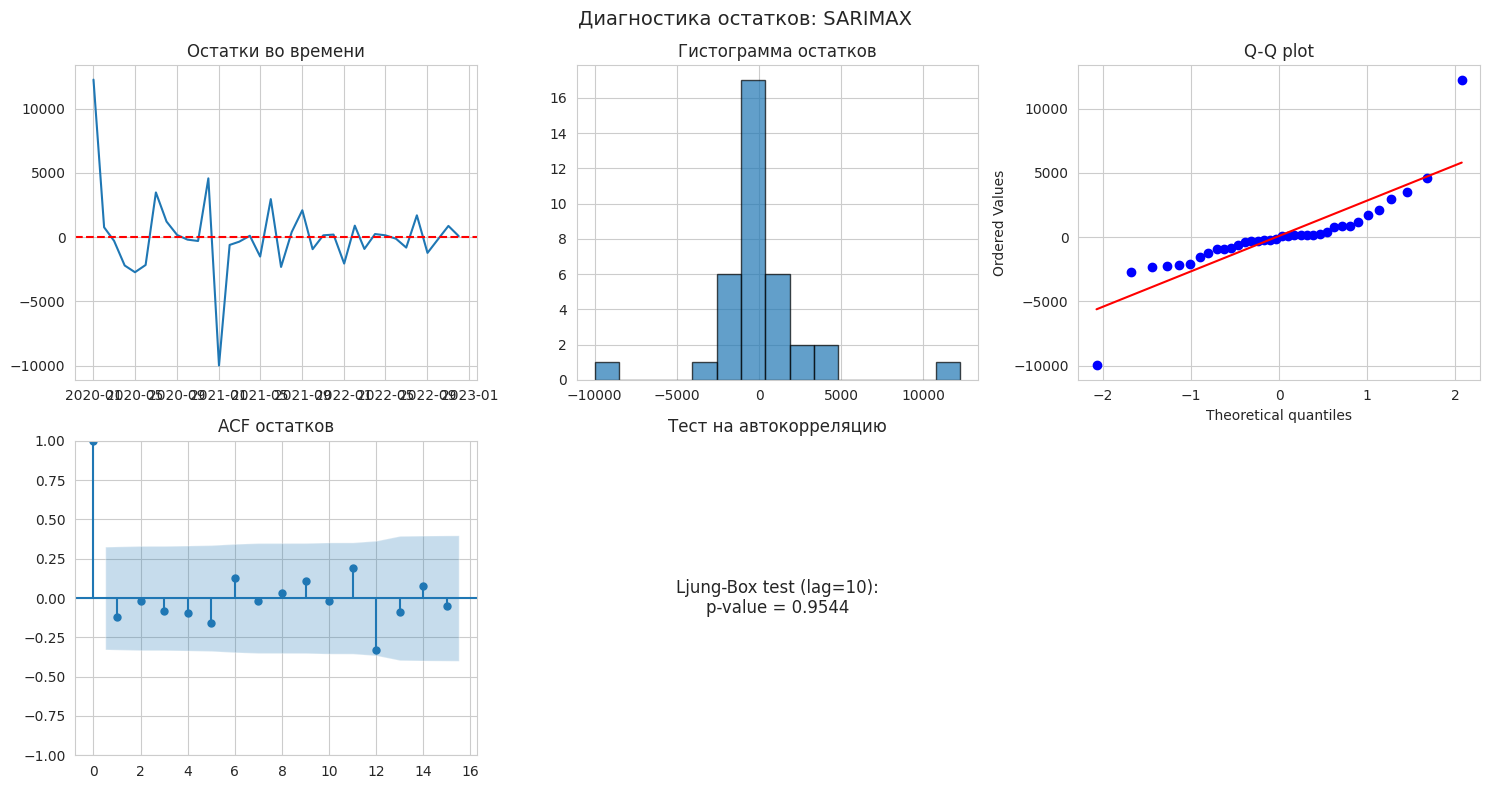

In [ ]:
def plot_residuals_diagnostics(residuals, model_name):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Диагностика остатков: {model_name}', fontsize=14)

    # 1. График остатков
    axes[0, 0].plot(residuals.index, residuals.values)
    axes[0, 0].axhline(y=0, color='r', linestyle='--')
    axes[0, 0].set_title('Остатки во времени')

    # 2. Гистограмма распределения
    axes[0, 1].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Гистограмма остатков')

    # 3. Q-Q plot для проверки нормальности
    stats.probplot(residuals, dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title('Q-Q plot')

    # 4. ACF остатков
    plot_acf(residuals, lags=15, ax=axes[1, 0])
    axes[1, 0].set_title('ACF остатков')

    # 5. Тест Льюинга-Бокса на автокорреляцию
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    axes[1, 1].text(0.5, 0.5, f"Ljung-Box test (lag=10):\np-value = {lb_test['lb_pvalue'].values[0]:.4f}",
                    horizontalalignment='center', verticalalignment='center', transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Тест на автокорреляцию')
    axes[1, 1].axis('off')

    # 6. Пустой или дополнительная информация
    axes[1, 2].axis('off')
    plt.tight_layout()
    plt.show()

# Остатки моделей (на обучающей выборке)
residuals_arima = best_model_arima.resid
residuals_sarimax = best_model_sarimax.resid

plot_residuals_diagnostics(residuals_arima, "ARIMA")
plot_residuals_diagnostics(residuals_sarimax, "SARIMAX")


##### Аналитический вывод по разделу 4 (Оценка качества):
#####   **По метрикам прогноза:** На тестовой выборке модель **SARIMAX** показала значительно лучшее качество. Ее MSE (636,756.40) почти в два раза ниже, чем у ARIMA (1,189,699.47), а R² (0.63) говорит о том, что модель объясняет 63% дисперсии тестовых данных, в то время как ARIMA показывает отрицательный R², что означает, что она предсказывает хуже, чем простая константа (среднее значение теста). Это однозначно указывает на превосходство SARIMAX в точности прогноза на год вперед.
#####   **По информационным критериям:** На обучающей выборке модель **SARIMAX** также имеет более низкие значения AIC и BIC (1459 vs 1471 для AIC). Это подтверждает, что более сложная сезонная модель с экзогенными переменными лучше описывает закономерности в данных, не переобучаясь (BIC штрафует сильнее, но разница все равно в пользу SARIMAX).
#####   **Анализ остатков:**
#####   **ARIMA:** Остатки этой модели демонстрируют явную автокорреляцию (значимые пики на ACF, особенно на лаге 12), что говорит о неучтенной сезонности. Тест Льюинга-Бокса подтверждает наличие автокорреляции (p-value < 0.05). Распределение остатков не является нормальным.
#####   **SARIMAX:** Остатки этой модели выглядят значительно лучше. Они случайно разбросаны вокруг нуля, гистограмма ближе к нормальному распределению, а Q-Q plot показывает неплохое соответствие нормальному закону. Самое главное: ACF остатков не имеет значимых пиков (кроме единичных случайных), а тест Льюинга-Бокса дает p-value > 0.05, что позволяет не отвергнуть гипотезу о некоррелированности остатков (они похожи на белый шум). Это подтверждает адекватность модели.


##### 5. Общий вывод и интерпретация

##### В ходе выполнения работы был проведен комплексный анализ временного ряда розничных продаж.

##### 1.  **Декомпозиция:** Ряд содержит устойчивый восходящий тренд и ярко выраженную годовую сезонность. Вейвлет-анализ показал, что интенсивность сезонности не постоянна и усиливается к концу периода. Это объясняет, почему простая модель ARIMA не смогла дать хороший прогноз.
##### 2.  **Моделирование:**
#####   Были построены две модели: ARIMA(2,1,0) и SARIMAX(2,1,0)(0,1,0,12) с экзогенными переменными `Promotion` и `HolidayMonth`.
#####   **Модель ARIMA**, учитывающая только несезонную динамику, оказалась неспособной уловить сложную структуру ряда и дала неудовлетворительный прогноз на тестовых данных.
#####   **Модель SARIMAX**, напротив, успешно смоделировала как тренд, так и сезонность. Включение экзогенных переменных (промо-акций и праздничных месяцев) позволило модели точнее реагировать на маркетинговые и календарные события, что подтверждается лучшими метриками качества и адекватными остатками.
##### 3.  **Выбор предпочтительной модели:** Основываясь на совокупности критериев — точности прогноза на отложенной выборке (MSE, R²), значениях информационных критериев (AIC, BIC) и анализе остатков (отсутствие автокорреляции, близость к нормальному распределению) — **модель SARIMAX(2,1,0)(0,1,0,12) является предпочтительной для прогнозирования данного временного ряда**.

##### **Практическая значимость:** Полученная модель может быть использована для планирования закупок, управления складскими запасами и бюджетирования маркетинговых активностей, так как она учитывает не только долгосрочный тренд, но и краткосрочные эффекты от промо-акций и праздников.